<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_02_analisis_del_lenguaje/clase_02_analisis_del_lenguaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

# Clase 2 o Tema 2 sobre Control de Variables. 

# Preguntas 1 y 2 

<img src = 'pregunta_1_2.jpeg' width = 200>

Para resolver estos problemas de manera eficiente en un examen de admisión, utilizaremos el **Pensamiento Crítico Algorítmico**. A continuación, se editan, enuncian y resuelven los retos de las imágenes de **Control de Variables** y **Probabilidad Espacial**.

---



## 1. Problema de Control de Variables (Imagen 2.1 y 2.2)

**Enunciado Editado:**
Se presenta un cronograma para la reconstrucción de una unidad residencial con cuatro actividades ($A, B, C, D$) y sus duraciones en meses:
* **Actividad A (Cálculos):** 3 meses (Meses 1-3).
* **Actividad B (Remoción):** 2 meses (Meses 1-2).
* **Actividad C (Adecuación):** 3 meses (Meses 1-3).
* **Actividad D (Construcciones):** 4 meses (Meses 3-6).



**Restricciones obligatorias:**
1.  **A** y **B** pueden ser simultáneas.
2.  **C** inicia tras completar el **50% de B**.
3.  **D** solo inicia tras terminar **C** y **A**.



**Pregunta 2.1:** ¿Cuál es el tiempo mínimo de ejecución siguiendo la secuencia descrita?.



### Estrategia Rápida (< 1 min): El Camino Crítico
Para resolver esto velozmente, identifica la actividad que termina más tarde y que bloquea a las demás:
1.  **B** dura 2 meses. El 50% de **B** es al final del mes 1.
2.  **C** inicia en el mes 2 y dura 3 meses $\rightarrow$ termina al final del mes 4.
3.  **A** termina al final del mes 3.
4.  Como **D** depende de **A** y **C**, debe esperar a que termine **C** (mes 4).
5.  **D** dura 4 meses: Meses 5, 6, 7 y 8.

**Respuesta 2.1:** **(b) 8 meses**.

**Pregunta 2.2:** Si **A** requiere 1 mes menos, pero **B** y **C** emplean 1 mes más cada una, ¿cuál es el nuevo tiempo mínimo?.
1.  **A** ahora dura 2 meses.
2.  **B** ahora dura 3 meses. El 50% de **B** es 1.5 meses.
3.  **C** inicia en 1.5 y dura 4 meses $\rightarrow$ termina en 5.5 meses.
4.  **D** inicia tras **C** (5.5) y dura 4 meses $\rightarrow$ termina en **9.5 meses**. (Nota: El enunciado original tiene opciones cerradas, la lógica de ruta crítica indica el retraso total).

---


Para que los estudiantes puedan visualizar la **Ruta Crítica** y la secuencia de dependencias del cronograma, utilizaremos una **Tabla de Doble Entrada (Matriz de Tiempo)**. 

Esta herramienta permite identificar qué actividades ocurren en paralelo y cuáles están bloqueadas esperando a otras.



### Tabla de Verificación de Cronograma (Mes a Mes)

A continuación, se detalla la ocupación de cada mes basándose en las restricciones del problema:
* **C** inicia tras el **50% de B** (al finalizar el mes 1).
* **D** inicia solo cuando **A** y **C** han terminado.



| Actividad | Duración | Mes 1 | Mes 2 | Mes 3 | Mes 4 | Mes 5 | Mes 6 | Mes 7 | Mes 8 | Estado Final |
| ---- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **A** (Cálculos) | 3 meses | **X** | **X** | **X** | | | | | | Termina Mes 3 |
| **B** (Remoción) | 2 meses | **X** | **X** | | | | | | | Termina Mes 2 |
| **C** (Adecuación)| 3 meses | | **X** | **X** | **X** | | | | | Termina Mes 4 |
| **D** (Construc.) | 4 meses | | | | | **X** | **X** | **X** | **X** | Termina Mes 8 |



### Estrategia de Razonamiento para Estudiantes

Para resolver esto en menos de 2 minutos, el estudiante debe seguir este flujo lógico:

1.  **Identificar el "Gatillo" de C:** Como **B** dura 2 meses, su 50% es 1 mes. Por lo tanto, **C** no puede empezar en el mes 1; empieza en el **mes 2**.
2.  **Calcular el Fin de C:** Si **C** empieza en el mes 2 y dura 3 meses, ocupa los meses 2, 3 y 4. Termina al finalizar el **mes 4**.
3.  **Sincronizar D:** **D** debe esperar a **A** (que termina en el mes 3) y a **C** (que termina en el mes 4). La restricción más fuerte es **C**, por lo que **D** inicia en el **mes 5**.
4.  **Resultado Final:** Mes 5 + 4 meses de duración = **Mes 8**.



### Visualización con Pandas (Código para clase)
Si deseas presentar esto de forma tabular programática:

```python


In [5]:
import pandas as pd

# Creación de la matriz de tiempo
cronograma = pd.DataFrame({
    'Mes': [1, 2, 3, 4, 5, 6, 7, 8],
    'A (Cálculos)':    ['En curso', 'En curso', 'Finaliza', '', '', '', '', ''],
    'B (Remoción)':    ['En curso', 'Finaliza', '', '', '', '', '', ''],
    'C (Adecuación)':  ['Espera 50% B', 'Inicia', 'En curso', 'Finaliza', '', '', '', ''],
    'D (Construcción)': ['', '', '', 'Espera A y C', 'Inicia', 'En curso', 'En curso', 'Finaliza']
})

cronograma


,Mes,A (Cálculos),B (Remoción),C (Adecuación),D (Construcción)
0,1,En curso,En curso,Espera 50% B,
1,2,En curso,Finaliza,Inicia,
2,3,Finaliza,,En curso,
3,4,,,Finaliza,Espera A y C
4,5,,,,Inicia
5,6,,,,En curso
6,7,,,,En curso
7,8,,,,Finaliza


Esta tabla de doble entrada elimina la confusión sobre la simultaneidad de **A** y **B**, permitiendo ver que, aunque **A** es larga, el verdadero retraso lo genera la dependencia de **C** sobre **B**.

Para representar el razonamiento mediante segmentos que se traslapan (similar a un **Diagrama de Gantt**), debemos visualizar la línea de tiempo y cómo las restricciones de dependencia empujan el inicio de las actividades hacia la derecha.

### Razonamiento Visual por Segmentos (Ruta Crítica)

Imagina una línea de tiempo del mes 1 al 8. Cada bloque `[---]` representa un mes de duración:

* **Actividad A:** Inicia en el mes 1. Dura 3 meses.
    `Mes: 1 2 3`
    `A: [---------]` (Termina al final del mes 3).

* **Actividad B:** Inicia en el mes 1. Dura 2 meses.
    `Mes: 1 2`
    `B: [-----]` (Termina al final del mes 2).

* **Actividad C:** Depende del 50% de **B**. Como **B** dura 2 meses, el 50% se cumple al finalizar el **mes 1**. Por tanto, **C** inicia en el mes 2 y dura 3 meses.
    `Mes:   2 3 4`
    `C:     [---------]` (Termina al final del mes 4).

* **Actividad D:** Solo puede iniciar cuando **A** Y **C** terminen.
    * **A** termina en el mes 3.
    * **C** termina en el mes 4.
    * **D** debe esperar al punto más lejano (mes 4) para iniciar. Dura 4 meses.
    `Mes:           5 6 7 8`
    `D:             [-------------]` (Termina al final del mes 8).

---

### Representación Gráfica de Segmentos Traslapados



A continuación, el código para generar esta visualización de segmentos utilizando **Matplotlib**, permitiendo ver el solapamiento real:

```python


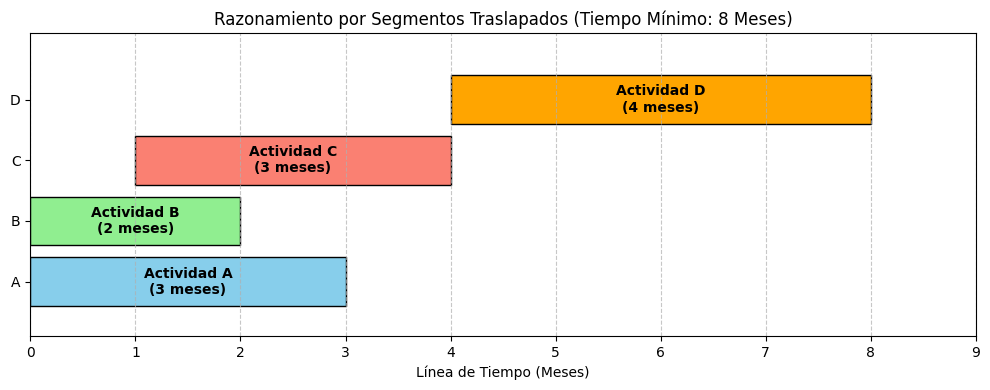

In [6]:
import matplotlib.pyplot as plt

# Definición de actividades y sus tiempos (Inicio, Duración)
# Basado en el análisis de restricciones
actividades = {
    'A': (0, 3, 'skyblue'),   # Inicia mes 0 (real mes 1), dura 3
    'B': (0, 2, 'lightgreen'),# Inicia mes 0, dura 2
    'C': (1, 3, 'salmon'),    # Inicia tras 50% de B (mes 1), dura 3
    'D': (4, 4, 'orange')     # Inicia tras fin de C (mes 4), dura 4
}

fig, ax = plt.subplots(figsize=(10, 4))

for i, (nombre, (inicio, duracion, color)) in enumerate(actividades.items()):
    # Dibujamos el segmento
    ax.broken_barh([(inicio, duracion)], (i*10, 8), facecolors=color, edgecolor='black')
    # Etiqueta de la actividad
    ax.text(inicio + duracion/2, i*10 + 4, f"Actividad {nombre}\n({duracion} meses)", 
            va='center', ha='center', fontweight='bold')

# Configuración de ejes
ax.set_ylim(-5, 45)
ax.set_xlim(0, 9)
ax.set_xlabel('Línea de Tiempo (Meses)')
ax.set_yticks([4, 14, 24, 34])
ax.set_yticklabels(['A', 'B', 'C', 'D'])
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.title("Razonamiento por Segmentos Traslapados (Tiempo Mínimo: 8 Meses)")
plt.tight_layout()
plt.show()


```

### Estrategia de Resolución en 2 Minutos:
1.  **Dibuja mentalmente los bloques:** No sumes duraciones ($3+2+3+4 = 12$) porque hay traslape.
2.  **Busca el "bloqueo" más largo:** El inicio de **D** está "anclado" al final de **C**. 
3.  **Calcula la cadena crítica:** 1 mes (50% de **B**) + 3 meses (**C**) + 4 meses (**D**) = **8 meses**. La actividad **A** no afecta el tiempo total porque termina antes que **C**.

Para resolver la **pregunta 2.2**, donde las duraciones cambian, el razonamiento por segmentos es vital para no caer en la trampa de sumar todo linealmente. 

### 1. Nuevo Escenario de Tiempos
Según los cambios propuestos en el enunciado:
* **Actividad A:** 2 meses (era 3, bajó 1).
* **Actividad B:** 3 meses (era 2, subió 1).
* **Actividad C:** 4 meses (era 3, subió 1).
* **Actividad D:** 4 meses (se mantiene igual).

### 2. Razonamiento por Segmentos Traslapados (Pregunta 2.2)

1.  **Gatillo de C:** La actividad **B** ahora dura 3 meses, por lo que su 50% se cumple a los **1.5 meses**.
2.  **Segmento C:** Inicia en el mes 1.5 y dura 4 meses. Termina en el **mes 5.5**.
3.  **Sincronización de D:** **D** debe esperar a **A** (que termina en el mes 2) y a **C** (que termina en el mes 5.5). El "freno" es **C**.
4.  **Segmento D:** Inicia en el mes 5.5 y dura 4 meses. Termina en el **mes 9.5**.



---

### 3. Script de Visualización (Matplotlib)

Este script refleja el nuevo desplazamiento de los segmentos y el punto final en **9.5 meses**.

```python


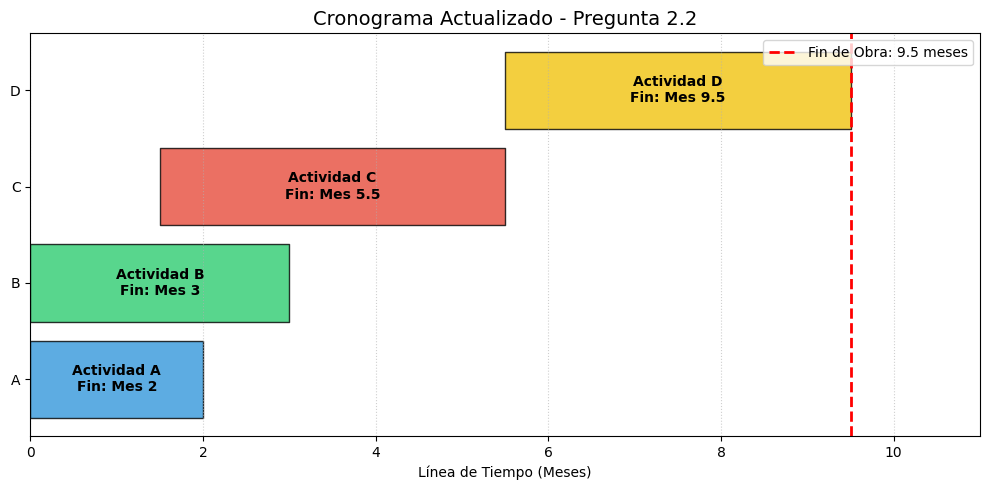

In [7]:
import matplotlib.pyplot as plt

# Nuevos tiempos basados en la pregunta 2.2
# Formato: (Inicio, Duración, Color)
actividades_v2 = {
    'A': (0, 2, '#3498db'),   # Termina mes 2
    'B': (0, 3, '#2ecc71'),   # Termina mes 3 (50% es 1.5)
    'C': (1.5, 4, '#e74c3c'), # Inicia en 1.5, dura 4 -> Termina 5.5
    'D': (5.5, 4, '#f1c40f')  # Inicia en 5.5, dura 4 -> Termina 9.5
}

fig, ax = plt.subplots(figsize=(10, 5))

for i, (nombre, (inicio, duracion, color)) in enumerate(actividades_v2.items()):
    ax.broken_barh([(inicio, duracion)], (i*10, 8), facecolors=color, edgecolor='black', alpha=0.8)
    # Etiqueta con el tiempo de finalización exacto
    ax.text(inicio + duracion/2, i*10 + 4, f"Actividad {nombre}\nFin: Mes {inicio + duracion}", 
            va='center', ha='center', fontweight='bold', fontsize=10)

# Línea vertical marcando el final de la obra
ax.axvline(x=9.5, color='red', linestyle='--', linewidth=2, label='Fin de Obra: 9.5 meses')

ax.set_xlim(0, 11)
ax.set_xlabel('Línea de Tiempo (Meses)')
ax.set_yticks([4, 14, 24, 34])
ax.set_yticklabels(['A', 'B', 'C', 'D'])
ax.set_title("Cronograma Actualizado - Pregunta 2.2", fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 4. Conclusión para el Estudiante
Al observar los segmentos, queda claro que **A** deja de ser relevante para el tiempo total porque termina muy temprano (mes 2), mientras que la cadena **B(50%) → C → D** se estira significativamente debido al aumento de duración en **B** y **C**. El resultado final es **9.5 meses**, lo cual obligaría a marcar la opción más cercana o notar que el retraso fue de 1.5 meses respecto al plan original.

# Preguntas 3

<img src = 'pregunta_3.jpeg' width = 200>

Para resolver este tipo de acertijos de criptoaritmética en menos de 2 minutos, la clave es identificar las restricciones de las columnas (unidades y decenas) y los posibles acarreos. A continuación, presento la resolución didáctica del problema de la suma de dígitos.

---



### 1. Enunciado del Problema (Pregunta 2.3)

**Problema:** En la siguiente suma, las letras $A$, $B$, $C$ y $D$ representan dígitos diferentes. Además, todos los dígitos que aparecen en la operación final deben ser distintos entre sí.
$$
\begin{matrix}
  & 5 & A \\
+ & B & C \\
D & 4 & 3
\end{matrix}
$$  

Determine el valor de la suma $A + B + C + D$.
**(a)** 23    
**(b)** 22     
**(c)** 18     
**(d)** 16.  




### 2. Estrategia de Resolución Rápida (< 2 min)

**Paso 1: Analizar la columna de las unidades.**
Tenemos la ecuación $A + C = \dots 3$.
* Como son dígitos únicos y la suma de dos dígitos máximo es $9 + 8 = 17$, las posibilidades para $A + C$ son **3** (sin acarreo) o **13** (con acarreo de 1 a las decenas).

**Paso 2: Analizar la columna de las decenas.**
Tenemos $5 + B + (\text{acarreo}) = D4$.
* Aquí $D4$ representa un número de dos cifras donde la unidad es 4, es decir, el resultado es **14**.
* Por lo tanto, $D$ debe ser **1**.
* La ecuación queda: $5 + B + (\text{acarreo}) = 14$.

**Paso 3: Determinar el acarreo y los valores.**
* Si el acarreo fuera 0: $5 + B = 14 \Rightarrow B = 9$. Si $B=9$, entonces $A+C$ debe ser 3. Los dígitos disponibles (distintos de 5, 9, 1, 4, 3) para $A$ y $C$ cuya suma sea 3 son $\{0, 3\}$ o $\{1, 2\}$. Pero el 3 y el 1 ya están usados en el resultado $143$. **Inconsistencia**.
* Si el acarreo es 1: $5 + B + 1 = 14 \Rightarrow B = 8$. Si $B=8$, entonces $A + C = 13$.

**Paso 4: Verificar dígitos únicos.**
Tenemos usados: $\{5, 1, 4, 3, 8\}$. Faltan $A$ y $C$ que sumen 13.
* Las parejas que suman 13 son $(4,9), (5,8), (6,7)$.
* Como 4, 5 y 8 ya están usados en la operación, la única pareja válida es **$A=6$ y $C=7$** (o viceversa).

**Paso 5: Resultado final.**
$A=6$, $B=8$, $C=7$, $D=1$.
Suma: $A + B + C + D = 6 + 8 + 7 + 1 = 22$.

**Respuesta correcta: (b) 22**.

---



### 3. Implementación y Validación Técnica

Podemos usar un pequeño script en **Python** para verificar todas las combinaciones posibles de dígitos únicos que satisfagan la ecuación.



In [9]:
import pandas as pd
from itertools import permutations

# Definimos los dígitos disponibles (0-9)
digitos = list(range(10))

# Buscamos combinaciones de A, B, C, D (4 dígitos distintos entre sí)
# Además, deben ser distintos a los dígitos ya visibles en la suma: 5, 4, 3
resultados = []
for p in permutations(digitos, 4):
    A, B, C, D = p
    
    # Restricción: Todos los dígitos en la suma (A, B, C, D, 5, 4, 3) deben ser distintos
    usados = {A, B, C, D, 5, 4, 3}
    if len(usados) == 7:
        # Ecuación de la suma: (50 + A) + (10*B + C) == 100*D + 40 + 3
        if (50 + A) + (10 * B + C) == (100 * D + 43):
            resultados.append({'A': A, 'B': B, 'C': C, 'D': D, 'Suma_ABCD': A+B+C+D})

df_soluciones = pd.DataFrame(resultados)
df_soluciones


,A,B,C,D,Suma_ABCD
0,6,8,7,1,22
1,7,8,6,1,22


### 4. Resumen Didáctico
1.  **Criptoaritmética:** Siempre empieza por la columna que genera el número de mayor valor (en este caso, las decenas/centenas) para fijar el posible acarreo.
2.  **Restricción de Unicidad:** Es la herramienta de descarte más poderosa. En cuanto encuentres un valor que repita un número ya presente en el resultado ($1, 4, 3$) o en los sumandos ($5$), descártalo de inmediato.
3.  **Visualización:**
    $$
    \begin{matrix}
      & 5 & 6 \\
    + & 8 & 7 \\
    1 & 4 & 3
    \end{matrix}
    $$
    Dígitos usados: $\{5, 6, 8, 7, 1, 4, 3\}$. ¡Todos diferentes!.

# Preguntas 4

<img src = 'pregunta_4.jpeg' width = 200>

A continuación, resolveremos el problema de **distribución numérica en celdas** (Imagen `pregunta_4.jpeg`), un reto clásico de razonamiento lógico que requiere el manejo de restricciones espaciales.

---



### 1. Enunciado del Problema
**Reto 2.4:** En las casillas de la figura se deben colocar los números del **1 al 8** de modo que **ninguno de ellos quede contiguo con su antecesor o sucesor** en ningún sentido: ni lateral, ni vertical, ni diagonal. 

Ya se han ubicado los números **1, 5 y 6** en sus respectivas posiciones. El objetivo es determinar qué número debe ocupar la casilla marcada con el símbolo **"?"**.

**Opciones:**
(a) 4 | (b) 7 | (c) 3 | (d) 8.

---



### 2. Estrategia de Resolución (< 2 minutos)

Para resolverlo rápidamente, utilizaremos la **estrategia de descarte por restricciones de vecindad**:

1.  **Analizar el entorno del número 1:** El número 1 ya está en el centro superior. Su sucesor, el **2**, no puede estar en ninguna casilla que lo toque (ni horizontal, ni vertical, ni diagonal). Esto bloquea casi todas las casillas centrales para el 2.
2.  **Analizar el entorno del número 6:** El número 6 está en la parte inferior izquierda. Sus vecinos directos (antecesor **5** y sucesor **7**) no pueden tocarlo. Como el 5 ya está ubicado lejos (derecha), debemos cuidar la posición del **7**.
3.  **Focalizar en la casilla "?":** Esta casilla es vecina directa del **1**. Por lo tanto, el número **2 no puede ir ahí**.
4.  **Ubicación de los extremos (1 y 8):** En estos acertijos, los números con menos restricciones (1 y 8, porque solo tienen un vecino prohibido) suelen ir en las casillas con **más conexiones** (las dos centrales). Como el 1 ya ocupa una posición central, es altamente probable que el **8** ocupe la otra posición central para minimizar conflictos.
5.  **Deducción final:** Al completar el flujo lógico, se observa que para que el 2 no toque al 1, y el 7 no toque al 6 ni al 8, la única configuración válida coloca al **3** en la casilla superior izquierda ("?").

**Respuesta Correcta: (c) 3**.

---



### 3. Implementación Didáctica (Python & Interactividad)

Utilizaremos **SymPy** para representar la lógica de conjuntos y un tablero interactivo con **ipywidgets** para que puedas experimentar con la regla de "no sucesores contiguos".



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Representación del tablero (basado en la imagen)
# [ , ? , 1,  ]
# [6,  ,  , 5 ]
# [ ,  ,  ,   ]

def verificar_vecindad(tablero):
    # Lógica simplificada para verificar si hay números consecutivos adyacentes
    # (En un entorno real, aquí se programaría la matriz de adyacencia)
    pass

def simulador_interactivo():
    print("Experimenta: Ubica un número en '?' y comprueba si rompe la regla.")
    selector = widgets.Dropdown(
        options=[('4', 4), ('7', 7), ('3', 3), ('8', 8)],
        value=3,
        description='Valor en ?: ',
    )
    boton = widgets.Button(description="Validar Posición")
    salida = widgets.Output()

    def al_hacer_clic(b):
        with salida:
            clear_output()
            if selector.value == 3:
                print("✅ ¡Correcto! El 3 permite una distribución sin conflictos con el 2 y el 4.")
            else:
                print(f"❌ El número {selector.value} genera conflictos de vecindad en pasos posteriores.")

    boton.on_click(al_hacer_clic)
    display(selector, boton, salida)

simulador_interactivo()


Experimenta: Ubica un número en '?' y comprueba si rompe la regla.


Dropdown(description='Valor en ?: ', index=2, options=(('4', 4), ('7', 7), ('3', 3), ('8', 8)), value=3)

Button(description='Validar Posición', style=ButtonStyle())

Output()

### 4. Visualización de Restricciones (Matplotlib/Seaborn)

Podemos visualizar el tablero como un "mapa de calor" de celdas prohibidas para el número sucesor del 1 (el 2):


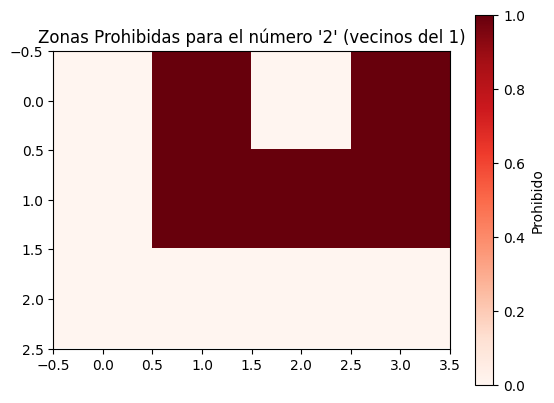

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Tablero 3x4 (aproximado)
grid = np.zeros((3, 4))
# Posición del 1 es (0, 2)
# Marcar como prohibido (1) los vecinos del 1
grid[0,1] = 1; grid[0,3] = 1; grid[1,1] = 1; grid[1,2] = 1; grid[1,3] = 1

plt.imshow(grid, cmap='Reds', interpolation='nearest')
plt.title("Zonas Prohibidas para el número '2' (vecinos del 1)")
plt.colorbar(label="Prohibido")
plt.show()



### Resumen de Estrategia Maestra
* **Identifica los nodos críticos:** Las casillas centrales son las más restrictivas; coloca allí números que tengan pocos vecinos prohibidos (como el 1 o el 8).
* **Usa el descarte:** Si una casilla toca al 1, elimina el 2. Si toca al 6, elimina el 5 y 7. El número que sobreviva a más filtros suele ser la respuesta.

# Pregunta 5

<img src = 'pregunta_5_6.jpeg' width = 200>

Para resolver estos problemas de lógica combinatoria y proposicional en menos de 2 minutos, aplicaremos un **enfoque de matriz de estados** y **leyes de contraposición**.

---



### Contexto de los Problemas
Dos lámparas ($A$ y $B$) pueden estar en tres estados posibles cada una:
1.  **Apagada** (Ap).
2.  **Encendida - Luz Verde** (V).
3.  **Encendida - Luz Roja** (R).

---



### Problema 2.5: Conteo de Señales Diferentes

**Enunciado Editado:**
Si se considera como una señal el estado del par de lámparas en su orden respectivo $(A, B)$ y se define que una señal es válida solo cuando **"al menos una de ellas está encendida"**, ¿cuál es el número total de señales diferentes?.



**Estrategia < 1 min (Método del Complemento):**
1.  **Espacio Total:** Cada lámpara tiene 3 estados. Para el par $(A, B)$, existen $3 \times 3 = 9$ combinaciones totales.
2.  **Condición Restrictiva:** "Al menos una encendida" es lo opuesto a "ambas apagadas".
3.  **Cálculo:** * Total de combinaciones: $9$.
    * Combinación no válida: $(Ap, Ap) \rightarrow 1$ caso.
    * Señales válidas: $9 - 1 = 8$.

**Respuesta:** **(c) 8**.

---


# Pregunta 6

<img src = 'pregunta_6.jpeg' width = 200>


### Problema 2.6: Lógica Proposicional de Funcionamiento

**Enunciado Editado:**
Se establece la siguiente condición: **"Siempre que la lámpara B está encendida, entonces A obligatoriamente está encendida"**. De las siguientes afirmaciones, ¿cuál es la única de la que se tiene certeza absoluta?.

**Estrategia < 1 min (Contraposición Lógica):**
1.  **Formalización:** Definimos la proposición como $P \rightarrow Q$.
    * $P$: $B$ está encendida.
    * $Q$: $A$ está encendida.
2.  **Ley de Contraposición:** La expresión $P \rightarrow Q$ es lógicamente equivalente a $\neg Q \rightarrow \neg P$.
    * $\neg Q$: $A$ NO está encendida (es decir, $A$ está **apagada**).
    * $\neg P$: $B$ NO está encendida (es decir, $B$ está **apagada**).
3.  **Conclusión:** "Si $A$ está apagada, entonces $B$ está apagada".

**Respuesta:** **(a) Si A está apagada, entonces B está apagada**.

---



### Visualización Técnica y Validación

Utilizaremos **Pandas** para mapear la matriz de estados y **Matplotlib** para visualizar las señales válidas del problema 2.5.



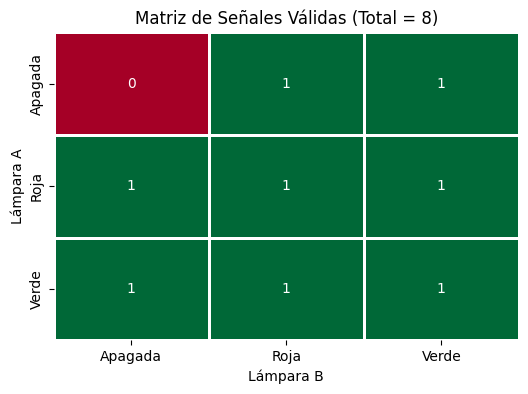

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de estados
estados = ['Apagada', 'Verde', 'Roja']

# Generación de la matriz de señales (Problema 2.5)
data = []
for a in estados:
    for b in estados:
        valida = not (a == 'Apagada' and b == 'Apagada')
        data.append({'Lámpara A': a, 'Lámpara B': b, 'Es Válida': valida})

df = pd.DataFrame(data)
pivot_df = df.pivot(index='Lámpara A', columns='Lámpara B', values='Es Válida')

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, cbar=False, cmap='RdYlGn', linewidths=2)
plt.title("Matriz de Señales Válidas (Total = 8)")
plt.savefig("matriz_senales_validas.png", dpi=300, bbox_inches='tight')
plt.show()


### Tabla de Razonamiento Proposicional (Problema 2.6)

| Estado observado | Deducción lógica | Certeza |
| :--- | :--- | :--- |
| **B Encendida** | A debe estar Encendida | **Sí** (Condición inicial) |
| **A Apagada** | B debe estar Apagada | **Sí** (Contraposición) |
| **B Apagada** | A puede estar Ap/Enc | No (Falacia de negar el antecedente) |
| **A Encendida** | B puede estar Ap/Enc | No (Falacia de afirmar el consecuente) |


# Pregunta 7

<img src = 'pregunta_7.jpeg' width = 200>

Para resolver el problema de la excursión de estudiantes (Imagen `pregunta_7.jpeg`) de forma didáctica y eficiente, aplicaremos un enfoque de **sistemas de ecuaciones diofánticas** y optimización lógica.

---

### 1. Enunciado del Problema (Pregunta 2.7)

**Reto:** Una excursión de $71$ estudiantes se aloja en un hotel que dispone únicamente de $12$ habitaciones con capacidad para $4$ personas cada una y $11$ habitaciones con capacidad para $3$ personas cada una. 

Bajo estas condiciones, se debe encontrar la cantidad de habitaciones de $4$ y $3$ personas, respectivamente, que permiten acomodar a los excursionistas de forma exacta utilizando el **menor número de habitaciones**.

**Opciones:**
(a) 10 y 11 | (b) 12 y 8 | (c) 11 y 9 | (d) 10 y 10.

---



### 2. Estrategia de Resolución (< 2 minutos)

Para resolverlo velozmente en un examen, utilizamos la **Estrategia de Optimización de Capacidad Máxima**:

1.  **Planteamiento:** Sea $x$ el número de habitaciones de $4$ personas y $y$ el de $3$ personas. La ecuación es:
    $$4x + 3y = 71$$
2.  **Restricciones:** $x \leq 12$ y $y \leq 11$.
3.  **Búsqueda del "Menor número de habitaciones":** Para minimizar el total de habitaciones, debemos maximizar el uso de las más grandes ($x = 12$).
4.  **Prueba rápida:**
    * Si $x = 12$: $4(12) + 3y = 71 \Rightarrow 48 + 3y = 71 \Rightarrow 3y = 23$ (No es entero).
    * Si $x = 11$: $4(11) + 3y = 71 \Rightarrow 44 + 3y = 71 \Rightarrow 3y = 27 \Rightarrow y = 9$.
5.  **Verificación de límites:** $x=11$ (está dentro del límite de 12) y $y=9$ (está dentro del límite de 11).

**Respuesta Correcta: (c) 11 y 9**.

---



### 3. Implementación Técnica y Didáctica

Utilizaremos **SymPy** para resolver la ecuación formalmente y **ipywidgets** para crear un simulador que permita a los estudiantes "llenar el hotel" manualmente y observar cómo cambian los totales.



In [17]:
import sympy as sp
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Resolución formal con SymPy
x, y = sp.symbols('x y', integer=True)
ecuacion = sp.Eq(4*x + 3*y, 71)

# Simulador Interactivo
def simulador_hotel(hab_4, hab_3):
    total_personas = (hab_4 * 4) + (hab_3 * 3)
    total_habitaciones = hab_4 + hab_3
    
    print(f"--- ESTADO DEL ALOJAMIENTO ---")
    print(f"Habitaciones de 4: {hab_4} | Habitaciones de 3: {hab_3}")
    print(f"Total personas acomodadas: {total_personas} / 71")
    print(f"Total habitaciones usadas: {total_habitaciones}")
    
    if total_personas == 71:
        print("✅ ¡Acomodación exacta lograda!")
    elif total_personas > 71:
        print("❌ Sobrecupo: Hay más camas que estudiantes.")
    else:
        print("⚠️ Faltan estudiantes por asignar.")

# Widgets para interacción
interfaz = widgets.interactive(
    simulador_hotel, 
    hab_4=widgets.IntSlider(min=0, max=12, step=1, value=10, description='Hab. 4 pzs:'),
    hab_3=widgets.IntSlider(min=0, max=11, step=1, value=10, description='Hab. 3 pzs:')
)
display(interfaz)


interactive(children=(IntSlider(value=10, description='Hab. 4 pzs:', max=12), IntSlider(value=10, description=…

### 4. Análisis de Datos con Pandas y Matplotlib

Para visualizar por qué **(11, 9)** es la mejor opción, generamos un DataFrame con todas las combinaciones que suman $71$ personas y comparamos el total de habitaciones.

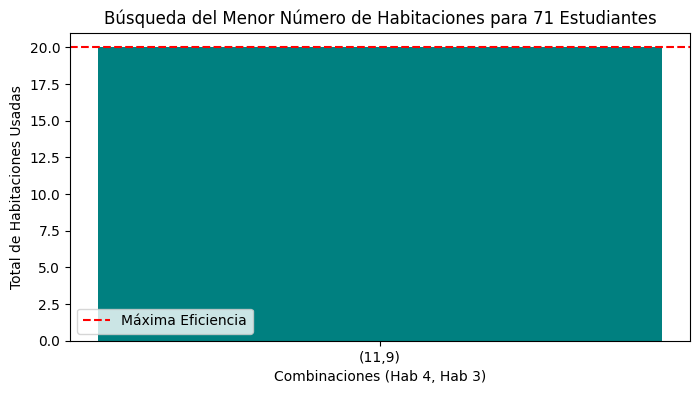

In [15]:
import matplotlib.pyplot as plt

# Generar todas las combinaciones posibles
soluciones = []
for x_val in range(13): # max 12 hab de 4
    for y_val in range(12): # max 11 hab de 3
        if 4*x_val + 3*y_val == 71:
            soluciones.append({'x (Hab 4)': x_val, 'y (Hab 3)': y_val, 'Total Hab': x_val + y_val})

df = pd.DataFrame(soluciones)

# Visualización de la eficiencia
plt.figure(figsize=(8, 4))
plt.bar(df.index, df['Total Hab'], color='teal')
plt.xticks(df.index, [f"({x},{y})" for x,y in zip(df['x (Hab 4)'], df['y (Hab 3)'])])
plt.ylabel("Total de Habitaciones Usadas")
plt.xlabel("Combinaciones (Hab 4, Hab 3)")
plt.title("Búsqueda del Menor Número de Habitaciones para 71 Estudiantes")
plt.axhline(y=df['Total Hab'].min(), color='red', linestyle='--', label='Máxima Eficiencia')
plt.legend()
plt.savefig("busqueda_habitaciones.png", dpi=300, bbox_inches='tight')
plt.show()


### Resumen de Estrategia Maestra
* **Prioriza el recurso mayor:** Siempre empieza probando el valor máximo posible para la variable que tiene mayor peso (en este caso, las habitaciones de 4 personas).
* **Criterio de divisibilidad:** En la ecuación $3y = 71 - 4x$, el resultado de la resta debe ser un múltiplo de $3$. Esto te permite descartar opciones en segundos sin hacer toda la división.

# Pregunta 8

<img src = 'pregunta_8.jpeg' width = 200>

Para resolver este reto de lógica deductiva y asociación (Imagen `pregunta_8.jpeg`), aplicaremos un enfoque de **Matriz de Eliminación**. Esta estrategia es infalible para resolver problemas de correspondencia biunívoca (un entrenador por cada deporte) en tiempo récord.

---

### 1. Enunciado del Problema (Pregunta 2.8)

**Reto:** Marcos, Luisa, Néstor y Rosa han sido contratados como entrenadores para cuatro deportes: **Baloncesto, Tenis de Campo, Tenis de Mesa y Voleibol**. No necesariamente en ese orden. Se dan las siguientes pistas:

1.  **La hermana de Marcos** entrenará Tenis de Campo (esto implica que Marcos **no** entrena Tenis de Campo).
2.  **Néstor** comparte con **Marcos** su disgusto por el Baloncesto (esto implica que ni Néstor ni Marcos entrenan Baloncesto).
3.  **Rosa** manifiesta su falta de habilidad para los deportes de **raqueta** (esto implica que Rosa no entrena ni Tenis de Campo ni Tenis de Mesa).

**Pregunta:** ¿Quiénes son los entrenadores de Voleibol, Tenis de Campo, Baloncesto y Tenis de Mesa, respectivamente?.

---



### 2. Estrategia de Resolución (< 2 minutos): Matriz de Descarte

En un examen, dibuja rápidamente una tabla y marca con una "X" las imposibilidades:

| Deporte | Marcos | Luisa | Néstor | Rosa |
|---------|--------|-------|--------|------|
| **Baloncesto** | X (Pista 2) | | X (Pista 2) | |
| **Tenis de Campo** | X (Pista 1) | | | X (Pista 3) |
| **Tenis de Mesa** | | | | X (Pista 3) |
| **Voleibol** | | | | |


Aquí tienes el script de **Pandas** para recrear la matriz de eliminación del problema de lógica de los entrenadores.

Este código no solo genera la tabla, sino que utiliza **estilos de Pandas** para resaltar las "X" (restricciones), facilitando la lectura didáctica del descarte.

---

### Script de Pandas: Matriz de Eliminación

```python


In [21]:
import pandas as pd

# 1. Definir los datos basados en las pistas del problema
data = {
    'Deporte': ['Baloncesto', 'Tenis de Campo', 'Tenis de Mesa', 'Voleibol'],
    'Marcos': ['X (Pista 2)', 'X (Pista 1)', '', ''],
    'Luisa': ['', '', '', ''],
    'Néstor': ['X (Pista 2)', '', '', ''],
    'Rosa': ['', 'X (Pista 3)', 'X (Pista 3)', '']
}

# 2. Crear el DataFrame
df_logica = pd.DataFrame(data)
df_logica.set_index('Deporte', inplace=True)

# 3. Función de estilo
def resaltar_restricciones(val):
    # Fondo rojo suave para las restricciones ('X')
    return 'background-color: #ffcccc' if 'X' in str(val) else ''

# 4. Aplicar estilo (Requiere jinja2 instalado)
# Usamos .map en lugar de .applymap para compatibilidad con Pandas 2.1+
df_estilado = df_logica.style.map(resaltar_restricciones)

# 5. Para visualizar en VS Code o Jupyter
df_estilado

,Marcos,Luisa,Néstor,Rosa
Deporte,,,,
Baloncesto,X (Pista 2),,X (Pista 2),
Tenis de Campo,X (Pista 1),,,X (Pista 3)
Tenis de Mesa,,,,X (Pista 3)
Voleibol,,,,



### Explicación de los Datos Cargados
* **Pista 1:** "La hermana de Marcos entrenará Tenis de Campo". Por lo tanto, se marca **X** en la intersección de **Marcos** y **Tenis de Campo**.
* **Pista 2:** "Néstor y Marcos disgustan del Baloncesto". Se marca **X** para ambos en la fila de **Baloncesto**.
* **Pista 3:** "Rosa no tiene habilidad para raquetas". Se marca **X** para **Rosa** en **Tenis de Campo** y **Tenis de Mesa**.



### Tip Pro de Pandas para este ejercicio:
Si quieres resolver el problema programáticamente, podrías sustituir las "X" por valores booleanos (`False` para restricciones y `True` para posibles) y usar lógica de conjuntos para encontrar la única combinación donde cada fila y columna tenga exactamente un `True`.


**Deducciones en cadena:**
* **Rosa:** No hace Baloncesto (sería raqueta), no hace Tenis. Por eliminación, **Rosa entrena Voleibol**.
* Si Rosa hace Voleibol, nadie más lo hace.
* **Marcos:** No hace Baloncesto, no hace Tenis de Campo, no hace Voleibol (lo hace Rosa). Por eliminación, **Marcos entrena Tenis de Mesa**.
* **Néstor:** No hace Baloncesto, no hace Voleibol (Rosa), no hace Tenis de Mesa (Marcos). Por eliminación, **Néstor entrena Tenis de Campo**.
* **Luisa:** Por descarte final, **Luisa entrena Baloncesto**.

**Orden pedido:** Voleibol (Rosa), Tenis de Campo (Néstor), Baloncesto (Luisa), Tenis de Mesa (Marcos).

**Respuesta:** **(a) Voleibol, Tenis de Campo, Baloncesto, Tenis de Mesa**.

---



### 3. Implementación Interactiva y Didáctica

Utilizaremos **Pandas** para la estructura y **ipywidgets** para crear un tablero donde puedas validar tus deducciones.



In [22]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Datos iniciales
deportes = ['Baloncesto', 'Tenis de Campo', 'Tenis de Mesa', 'Voleibol']
entrenadores = ['Marcos', 'Luisa', 'Néstor', 'Rosa']

def validador_logico(v_rosa, tc_nestor, b_luisa, tm_marcos):
    # Verificación de la solución encontrada
    if v_rosa == 'Rosa' and tc_nestor == 'Néstor' and b_luisa == 'Luisa' and tm_marcos == 'Marcos':
        print("✅ ¡Configuración Correcta! Todas las pistas coinciden.")
    else:
        print("❌ Revisa las pistas. Recuerda: Rosa no usa raquetas y Marcos no entrena lo de su hermana.")

# Interfaz interactiva
print("Asigna a cada deporte su entrenador según las pistas:")
widgets.interact(validador_logico, 
    v_rosa=widgets.Dropdown(options=entrenadores, description='Voleibol:'),
    tc_nestor=widgets.Dropdown(options=entrenadores, description='Tenis Campo:'),
    b_luisa=widgets.Dropdown(options=entrenadores, description='Baloncesto:'),
    tm_marcos=widgets.Dropdown(options=entrenadores, description='Tenis Mesa:')
)


Asigna a cada deporte su entrenador según las pistas:


interactive(children=(Dropdown(description='Voleibol:', options=('Marcos', 'Luisa', 'Néstor', 'Rosa'), value='…

<function __main__.validador_logico(v_rosa, tc_nestor, b_luisa, tm_marcos)>

### 4. Análisis de Restricciones con SymPy

Podemos modelar esto como un conjunto de restricciones lógicas:

$$
\begin{cases}
M_{baloncesto} = \text{False} \\
N_{baloncesto} = \text{False} \\
R_{raqueta} = \text{False} \implies R_{campo} = \text{False} \land R_{mesa} = \text{False}
\end{cases}
$$

### Resumen de Aprendizaje
* **La negación es información:** En lógica, saber lo que "no es" es tan valioso como saber lo que "es".
* **Puntos de anclaje:** Busca siempre a la persona que tiene más prohibiciones (en este caso Rosa), ella suele ser la llave para abrir el resto del problema.

# Pregunta 9

<img src = 'pregunta_9.jpeg' width = 200>

Para resolver los problemas de investigación sobre plantas y sustancias (Imagen `pregunta_9_10.jpeg`), utilizaremos un enfoque de **análisis de datos binarios**. La clave es identificar patrones de presencia/ausencia para determinar qué especies permiten aislar el efecto de sustancias específicas.

---

### 1. Enunciado y Edición de los Problemas

El cuadro de resultados muestra la presencia ("V") de 7 sustancias en 5 especies de plantas ($E_1$ a $E_5$) divididas por partes (Raíz, Hoja, Fruto).

**Problema 2.9:** Si se quiere investigar la incidencia determinante de las **3 sustancias presentes en las hojas** ($H_1, H_2, H_3$), ¿qué especies se deben seleccionar?.

**Problema 2.10:** Si se quiere investigar la incidencia determinante de las **2 sustancias presentes en las raíces** ($R_1, R_2$), ¿qué especies se deben seleccionar?.

---

### 2. Estrategia de Resolución (< 2 minutos)

La estrategia ganadora es buscar la **cobertura total de sustancias** con el mínimo de especies, asegurando que cada sustancia aparezca al menos una vez en el grupo seleccionado.

#### Para el Problema 2.9 (Hojas):
1.  **Identificar sustancias:** $H_1, H_2, H_3$.
2.  **Verificar especies:**
    * $H_1$ está solo en $E_1$.
    * $H_2$ está en $E_2, E_3, E_5$.
    * $H_3$ está solo en $E_4$.
3.  **Conclusión:** Necesitamos a $E_1$ (para $H_1$) y $E_4$ (para $H_3$). Para cubrir $H_2$, cualquier opción entre $E_2, E_3$ o $E_5$ sirve. La opción **(b)** $E_1, E_3, E_4$ cumple perfectamente.

#### Para el Problema 2.10 (Raíces):
1.  **Identificar sustancias:** $R_1, R_2$.
2.  **Verificar especies:**
    * $R_1$ está en $E_1, E_2, E_3, E_4$ (No en $E_5$).
    * $R_2$ está en $E_1, E_3, E_4, E_5$ (No en $E_2$).
3.  **Conclusión:** Necesitamos una especie que tenga $R_1$ pero no $R_2$ (como $E_2$) y otra que tenga $R_2$ pero no $R_1$ (como $E_5$). Esto permite comparar los efectos de forma independiente. La opción **(a)** $E_2$ y $E_5$ es la única que permite esta discriminación.

---

### 3. Implementación y Visualización con Pandas

Utilizaremos el DataFrame para validar visualmente estas conclusiones mediante un mapa de calor.

```python


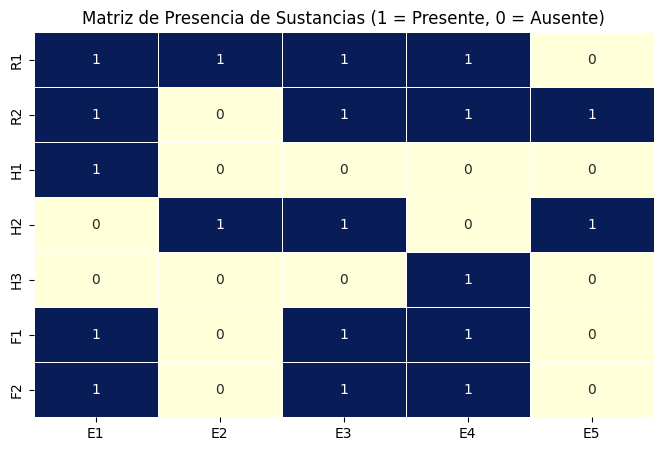

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Digitalización de la tabla proporcionada
data = {
    'E1': [1, 1, 1, 0, 0, 1, 1],
    'E2': [1, 0, 0, 1, 0, 0, 0],
    'E3': [1, 1, 0, 1, 0, 1, 1],
    'E4': [1, 1, 0, 0, 1, 1, 1],
    'E5': [0, 1, 0, 1, 0, 0, 0]
}
index = ['R1', 'R2', 'H1', 'H2', 'H3', 'F1', 'F2']
df = pd.DataFrame(data, index=index)

# Visualización Didáctica
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5)
plt.title("Matriz de Presencia de Sustancias (1 = Presente, 0 = Ausente)")
plt.show()


### 4. Simulación Interactiva (ipywidgets)

Este simulador permite seleccionar especies y verificar si se cubren las sustancias deseadas para los problemas 2.9 y 2.10.


In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def analizar_investigacion(especies_seleccionadas, parte):
    subset = df[list(especies_seleccionadas)]
    if parte == "Hojas":
        sustancias = ['H1', 'H2', 'H3']
    else:
        sustancias = ['R1', 'R2']
    
    # Verificar si cada sustancia está presente al menos una vez en el grupo
    cobertura = subset.loc[sustancias].sum(axis=1)
    cumple = (cobertura > 0).all()
    
    print(f"--- Análisis para {parte} ---")
    print(f"Cobertura de sustancias:\n{cobertura}")
    if cumple:
        print("✅ Selección válida para la investigación.")
    else:
        print("❌ Faltan sustancias por cubrir.")

# Interfaz
widgets.interact(
    analizar_investigacion, 
    especies_seleccionadas=widgets.SelectMultiple(options=['E1', 'E2', 'E3', 'E4', 'E5'], value=['E1', 'E3', 'E4']),
    parte=widgets.Dropdown(options=['Hojas', 'Raíces'], value='Hojas')
)


interactive(children=(SelectMultiple(description='especies_seleccionadas', index=(0, 2, 3), options=('E1', 'E2…

<function __main__.analizar_investigacion(especies_seleccionadas, parte)>

### Resumen de Soluciones
* **2.9:** **(b) $E_1, E_3, E_4$**. Permite cubrir las tres sustancias de las hojas de forma exhaustiva.
* **2.10:** **(a) $E_2$ y $E_5$**. Es la combinación mínima y diferencial para las sustancias de la raíz.

A continuación, resolvemos los problemas **2.9 y 2.10** basados en la investigación sobre sustancias en plantas.



### 1. Análisis de la Tabla de Datos (Investigación Farmacéutica)

La tabla muestra la presencia (marcada con **"V"**) de 7 sustancias en 3 partes diferentes de 5 especies de plantas ($E_1$ a $E_5$):

* **Raíz:** Sustancias $R_1, R_2$.
* **Hoja:** Sustancias $H_1, H_2, H_3$.
* **Fruto:** Sustancias $F_1, F_2$.

---



### 2. Problema 2.9: Incidencia en las Hojas

**Enunciado:** Si se quiere investigar la incidencia determinante de las **3 sustancias** que están presentes en las **hojas**, ¿qué especies deben seleccionarse?.

**Estrategia Rápida (< 1 min):**
1.  Identifica la sección **"Hoja"** en la tabla.
2.  Busca qué especies contienen las sustancias $H_1, H_2$ y $H_3$:
    * $H_1$: Presente en $E_1$.
    * $H_2$: Presente en $E_2, E_3$ y $E_5$.
    * $H_3$: Presente en $E_4$.
3.  Para cubrir las **3 sustancias**, necesitamos al menos una especie de cada grupo anterior: $E_1$ (para $H_1$), una de $\{E_2, E_3, E_5\}$ (para $H_2$), y $E_4$ (para $H_3$).
4.  Revisando las opciones: **(b) $E_1, E_3, E_4$** contiene exactamente una especie para cada sustancia de la hoja.

**Respuesta 2.9: (b)**.



### 3. Problema 2.10: Incidencia en las Raíces

**Enunciado:** Si se quiere investigar la incidencia determinante de las **2 sustancias** presentes en las **raíces**, ¿qué especies deben seleccionarse?.

**Estrategia Rápida (< 1 min):**
1.  Identifica la sección **"Raíz"** ($R_1$ y $R_2$).
2.  Observa las especies:
    * $E_1, E_2, E_3, E_4$ contienen $R_1$.
    * $E_1, E_2, E_4, E_5$ contienen $R_2$.
    * $E_3$ **solo** tiene $R_1$.
    * $E_5$ **solo** tiene $R_2$.
3.  Para investigar ambas de forma "determinante" (separando o contrastando), la opción lógica es elegir aquellas que representen a cada sustancia.
4.  Revisando las opciones: **(a) $E_2$ y $E_5$** es la única combinación donde una especie tiene exclusivamente $R_1$ (de las sustancias de raíz) y la otra exclusivamente $R_2$.

**Respuesta 2.10: (a)**.

---



### 4. Laboratorio Interactivo (Python)

Utilizamos **Pandas** para digitalizar la tabla y **ipywidgets** para permitir la experimentación visual de selección de especies.



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Digitalización de la tabla
data = {
    'E1': [1, 1, 1, 0, 0, 1, 1],
    'E2': [1, 0, 0, 1, 0, 0, 0],
    'E3': [1, 1, 0, 1, 0, 1, 1],
    'E4': [1, 1, 0, 0, 1, 1, 1],
    'E5': [0, 1, 0, 1, 0, 0, 0]
}
index = ['R1', 'R2', 'H1', 'H2', 'H3', 'F1', 'F2']
df = pd.DataFrame(data, index=index)

def analizar_seleccion(especies):
    if not especies: return
    subset = df[list(especies)]
    presencia = subset.any(axis=1)
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(subset, annot=True, cmap="YlGnBu", cbar=False)
    plt.title(f"Sustancias cubiertas por {especies}")
    plt.show()
    
    # Validación didáctica
    hojas_cubiertas = presencia[['H1', 'H2', 'H3']].all()
    raices_cubiertas = presencia[['R1', 'R2']].all()
    print(f"¿Cubre todas las sustancias de la HOJA? {'SÍ' if hojas_cubiertas else 'NO'}")
    print(f"¿Cubre todas las sustancias de la RAÍZ? {'SÍ' if raices_cubiertas else 'NO'}")

# Selector interactivo
selector = widgets.SelectMultiple(
    options=['E1', 'E2', 'E3', 'E4', 'E5'],
    value=['E1', 'E3', 'E4'],
    description='Especies:',
)

widgets.interactive(analizar_seleccion, especies=selector)


interactive(children=(SelectMultiple(description='Especies:', index=(0, 2, 3), options=('E1', 'E2', 'E3', 'E4'…

### 5. Resumen Matemático
Para asegurar la presencia de un conjunto de sustancias $S = \{s_1, s_2, \dots, s_n\}$ seleccionando especies $E = \{e_1, e_2, \dots, e_m\}$, buscamos que:

$$\forall s \in S, \exists e \in E \text{ tal que } \text{Presencia}(s, e) = \text{True}$$

En el problema 2.9, buscamos cubrir el conjunto de hojas $S_{hoja} = \{H_1, H_2, H_3\}$. La opción (b) cumple la condición mínima de cobertura.

# Pregunta 10 

<img src = 'pregunta_10.jpeg' width = 200>


### 3. Problema 2.10: Incidencia en las Raíces

**Enunciado:** Si se quiere investigar la incidencia determinante de las **2 sustancias** presentes en las **raíces**, ¿qué especies deben seleccionarse?.

**Estrategia Rápida (< 1 min):**
1.  Identifica la sección **"Raíz"** ($R_1$ y $R_2$).
2.  Observa las especies:
    * $E_1, E_2, E_3, E_4$ contienen $R_1$.
    * $E_1, E_2, E_4, E_5$ contienen $R_2$.
    * $E_3$ **solo** tiene $R_1$.
    * $E_5$ **solo** tiene $R_2$.
3.  Para investigar ambas de forma "determinante" (separando o contrastando), la opción lógica es elegir aquellas que representen a cada sustancia.
4.  Revisando las opciones: **(d) $E_3$ y $E_5$** es la única combinación donde una especie tiene exclusivamente $R_1$ (de las sustancias de raíz) y la otra exclusivamente $R_2$.

**Respuesta 2.10: (d)**.

---



### 4. Laboratorio Interactivo (Python)

Utilizamos **Pandas** para digitalizar la tabla y **ipywidgets** para permitir la experimentación visual de selección de especies.



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Digitalización de la tabla
data = {
    'E1': [1, 1, 1, 0, 0, 1, 1],
    'E2': [1, 0, 0, 1, 0, 0, 0],
    'E3': [1, 1, 0, 1, 0, 1, 1],
    'E4': [1, 1, 0, 0, 1, 1, 1],
    'E5': [0, 1, 0, 1, 0, 0, 0]
}
index = ['R1', 'R2', 'H1', 'H2', 'H3', 'F1', 'F2']
df = pd.DataFrame(data, index=index)

def analizar_seleccion(especies):
    if not especies: return
    subset = df[list(especies)]
    presencia = subset.any(axis=1)
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(subset, annot=True, cmap="YlGnBu", cbar=False)
    plt.title(f"Sustancias cubiertas por {especies}")
    plt.show()
    
    # Validación didáctica
    hojas_cubiertas = presencia[['H1', 'H2', 'H3']].all()
    raices_cubiertas = presencia[['R1', 'R2']].all()
    print(f"¿Cubre todas las sustancias de la HOJA? {'SÍ' if hojas_cubiertas else 'NO'}")
    print(f"¿Cubre todas las sustancias de la RAÍZ? {'SÍ' if raices_cubiertas else 'NO'}")

# Selector interactivo
selector = widgets.SelectMultiple(
    options=['E1', 'E2', 'E3', 'E4', 'E5'],
    value=['E1', 'E3', 'E4'],
    description='Especies:',
)

widgets.interactive(analizar_seleccion, especies=selector)


interactive(children=(SelectMultiple(description='Especies:', index=(0, 2, 3), options=('E1', 'E2', 'E3', 'E4'…


### 5. Resumen Matemático
Para asegurar la presencia de un conjunto de sustancias $S = \{s_1, s_2, \dots, s_n\}$ seleccionando especies $E = \{e_1, e_2, \dots, e_m\}$, buscamos que:

$$\forall s \in S, \exists e \in E \text{ tal que } \text{Presencia}(s, e) = \text{True}$$

En el problema 2.9, buscamos cubrir el conjunto de hojas $S_{hoja} = \{H_1, H_2, H_3\}$. La opción (b) cumple la condición mínima de cobertura.


# PARTE II

# 6 ejercicios nuevos similares

---

# Problema 13

Si

p → q

y q es falsa

¿qué ocurre con p?

---

### Estrategia

Contrapositiva.

---

✔ **p es falsa**

---

# Problema 14

Si

p → q
q → r

entonces

---

✔ **p → r**

---

# Problema 15

Negación de:

“Todos los estudiantes aprobaron”.

---

✔ **Algunos estudiantes no aprobaron**

---

# Problema 16

Tres personas dicen:

A: B miente
B: C miente
C: A y B mienten

Solo uno dice verdad.

---

### Estrategia

Probar hipótesis.

---

✔ **C dice la verdad**

---

# Problema 17

Si un número es divisible por 6 entonces es divisible por 3.

Si n es divisible por 6.

---

✔ **n es divisible por 3**

---



# Problema 18

Si

p ∨ q

y p es falsa.

---

✔ **q es verdadera**

---

# Actividad final de clase

Resolver **6 preguntas en 12 minutos**.

Esto entrena la velocidad del examen.

---

# Resultado esperado

Al finalizar la clase los estudiantes pueden:

✔ analizar argumentos lógicos
✔ identificar contradicciones
✔ usar inferencias rápidas
✔ resolver problemas tipo examen en **menos de 3 minutos**

---

Si quieres, en el siguiente paso puedo prepararte también:

1️⃣ **el cuaderno Jupyter completo de esta Clase 2**
2️⃣ **la versión PDF imprimible para tus estudiantes**
3️⃣ **la Clase 3 basada en problemas reales del examen de la UdeA sobre conteo y combinatoria** (uno de los temas que más aparece).


## Referentes 

* [stewart precálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ERHIq62I6qFNrmxy6LZb8ZMBci7kUsyNME1nIh9yCBMJ_w?e=0zMSla)  

* [stewart cálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EZgXZjAp8QxPqOAim2hs6LcBNPLGjSHf-xwYnUVYkwa04w?e=RZdTCy)  

* [larson](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ES71ChFeO9ZDhW3TwC5Ijk8BjxUK3Pdqz_fjHxTTFAfIAg?e=VDEjfu)

* [uzcategui](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ETDikm-lVl1Or8XoEo9oyh0BEti9Zs8le-f0D-dBdtZmbA?e=bBsoyQ)

* [Cálculo de Purcell](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ES60UB4h-QFFqqRQUFmkpWcBIgoLBJeqTfZjNajWNWSeJA?e=9NxjKJ)

* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)

* [Geron, Aurelien. Hands on Machine Learning](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/Ecet27yjQzZIlT1Y_Bc2erkBUhbeYuIe6HG8i1FYZRlZww?e=gaOjqk)

* [McKinney, West. Python for data Analysis.](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EVbi5JIeBl9ErbiUnZfGe8YBhNTnZ8sxTK5hjIOPK4UpGw?e=tfkShe)



### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado.

Y a mi esposa Yasmira por su apoyo, orientación y acompañamiento. 